# Modular Fair-RAG Recreation (T5 Small + BM25)

This notebook is designed to scale across machines by changing only one config profile.

Profiles:
- `weak`: 5 queries, small samples
- `balanced`: more queries and samples
- `strong`: intended for a better machine/full recreation

Output focus: normalized EE-D interval buckets (`0.0-0.2 ... 0.8-1.0`) and EU differences.

In [5]:
from pathlib import Path
import importlib
import pandas as pd

import notebook_experiment_utils as neu
importlib.reload(neu)

ExperimentConfig = neu.ExperimentConfig
find_repo_root = neu.find_repo_root
resolve_python_executable = neu.resolve_python_executable
ensure_paths_exist = neu.ensure_paths_exist
run_experiment_for_alpha = neu.run_experiment_for_alpha
run_targeted_qids_for_alpha = neu.run_targeted_qids_for_alpha
find_degenerate_score_qids = neu.find_degenerate_score_qids
find_invalid_result_qids = neu.find_invalid_result_qids
run_gold_baseline = neu.run_gold_baseline
run_retriever_grid = neu.run_retriever_grid
run_deterministic_reference = neu.run_deterministic_reference
run_mmr_deterministic = neu.run_mmr_deterministic
run_gold_deterministic_reference = neu.run_gold_deterministic_reference
normalize_eu_grid = neu.normalize_eu_grid
normalize_eu_for_retriever = neu.normalize_eu_for_retriever
load_normalized_rows = neu.load_normalized_rows
load_normalized_rows_for_retriever = neu.load_normalized_rows_for_retriever
load_raw_rows = neu.load_raw_rows
raw_results_path = neu.raw_results_path
add_ee_d_interval_bins = neu.add_ee_d_interval_bins
summarize_by_interval = neu.summarize_by_interval
interval_pvalues_vs_deterministic = neu.interval_pvalues_vs_deterministic
save_interval_outputs = neu.save_interval_outputs
save_per_query_log = neu.save_per_query_log
save_pvalue_outputs = neu.save_pvalue_outputs
reset_run_outputs = neu.reset_run_outputs
assert_consistent_qids_across_alphas = neu.assert_consistent_qids_across_alphas


In [6]:
ROOT = find_repo_root()
PY = resolve_python_executable(ROOT)

profiles = {
    'weak': {
        'max_queries': 30,
        'n_samples': 10,
        'k': 5,
        'print_interval': 10,
    },
    'balanced': {
        'max_queries': 833,
        'n_samples': 12,
        'k': 5,
        'print_interval': 40,
    },
    'strong': {
        'max_queries': None,
        'n_samples': 100,
        'k': 5,
        'print_interval': 100,
    },
}

# Change only this line when moving to a stronger machine
profile_name = 'balanced'
profile = profiles[profile_name]

cfg = ExperimentConfig(
    root=ROOT,
    python_exe=PY,
    generator_name='flanT5Small',
    lamp_num=4,
    retriever_name='bm25',
    alphas=(1, 2, 4, 8),
    max_queries=profile['max_queries'],
    n_samples=profile['n_samples'],
    k=profile['k'],
    remove_temp_files=True,
    skip_existing=True,
    mmr_base_retriever='bm25',
    mmr_lambda=0.6,
    run_tag=profile_name,
    print_interval=profile['print_interval'],
 )

ensure_paths_exist([cfg.python_exe])

print('Root   :', ROOT)
print('Python :', cfg.python_exe)
print('Profile:', profile_name)
print('Config :', cfg)


Root   : /Users/asimk/Code/Fair-RAG
Python : /Users/asimk/Code/Fair-RAG/.venv/bin/python
Profile: balanced
Config : ExperimentConfig(root=PosixPath('/Users/asimk/Code/Fair-RAG'), python_exe=PosixPath('/Users/asimk/Code/Fair-RAG/.venv/bin/python'), generator_name='flanT5Small', lamp_num=4, retriever_name='bm25', alphas=(1, 2, 4, 8), max_queries=833, n_samples=12, k=5, remove_temp_files=True, skip_existing=True, mmr_base_retriever='bm25', mmr_lambda=0.6, run_tag='balanced', print_interval=40)


## Run Controls
Toggle stages independently. Baselines run first (deterministic BM25 + deterministic MMR).

In [8]:
RUN_GOLD = True

RUN_GOLD_ALPHA_SWEEP = True

RUN_DETERMINISTIC_REF = True

RUN_MMR_DETERMINISTIC = True

RUN_MMR_ON_GOLD_DETERMINISTIC = True

RUN_GOLD_DETERMINISTIC = True  # deterministic oracle: gold docs, fixed order, no PL sampling

RUN_MMR_LAMBDA_SWEEP = False   # already chose lambda=0.6; no sweep needed

RUN_BASELINE_SUMMARY = True



RUN_BM25_GRID = False

RUN_NORMALIZE_EU = True

RUN_SANITY = True

RUN_ANALYSIS = True



# Deterministic references use one alpha only; value is for naming consistency.

DETERMINISTIC_ALPHA = 1

GOLD_ALPHA_SWEEP = (1, 8)

MMR_LAMBDAS = (0.6,)



# Sanity checks: oracle + stochastic BM25 across alphas on a small subset.

SANITY_MAX_QUERIES = 12

SANITY_N_SAMPLES = 10

SANITY_ALPHAS = (1, 2, 4, 8)

SANITY_GOLD_ALPHA = 8

SANITY_OUTPUT_SUFFIX = '_sanity'



# IMPORTANT for long runs on unstable servers:

# Keep this False so completed outputs are preserved and reruns resume safely.

FORCE_FRESH_RUN = False


In [ ]:
import time

from datetime import datetime





def run_stage(name, enabled, fn):

    if not enabled:

        print(f'[skip] {name}')

        return

    print(f"\n=== START {name} @ {datetime.now().strftime('%H:%M:%S')} ===")

    t0 = time.time()

    fn()

    dt_sec = time.time() - t0

    print(f'=== DONE {name} in {dt_sec/60:.2f} min ===')





def build_sanity_cfg():

    return ExperimentConfig(

        root=cfg.root,

        python_exe=cfg.python_exe,

        generator_name=cfg.generator_name,

        lamp_num=cfg.lamp_num,

        retriever_name=cfg.retriever_name,

        alphas=SANITY_ALPHAS,

        max_queries=SANITY_MAX_QUERIES,

        n_samples=SANITY_N_SAMPLES,

        k=cfg.k,

        remove_temp_files=cfg.remove_temp_files,

        skip_existing=False,

        mmr_base_retriever=cfg.mmr_base_retriever,

        mmr_lambda=cfg.mmr_lambda,

    )





def build_cfg_with_mmr_lambda(mmr_lambda):

    return ExperimentConfig(

        root=cfg.root,

        python_exe=cfg.python_exe,

        generator_name=cfg.generator_name,

        lamp_num=cfg.lamp_num,

        retriever_name=cfg.retriever_name,

        alphas=cfg.alphas,

        max_queries=cfg.max_queries,

        n_samples=cfg.n_samples,

        k=cfg.k,

        remove_temp_files=cfg.remove_temp_files,

        skip_existing=cfg.skip_existing,

        mmr_base_retriever=cfg.mmr_base_retriever,

        mmr_lambda=mmr_lambda,

    )





def build_cfg_with_mmr_base_retriever(mmr_base_retriever):

    return ExperimentConfig(

        root=cfg.root,

        python_exe=cfg.python_exe,

        generator_name=cfg.generator_name,

        lamp_num=cfg.lamp_num,

        retriever_name=cfg.retriever_name,

        alphas=cfg.alphas,

        max_queries=cfg.max_queries,

        n_samples=cfg.n_samples,

        k=cfg.k,

        remove_temp_files=cfg.remove_temp_files,

        skip_existing=cfg.skip_existing,

        mmr_base_retriever=mmr_base_retriever,

        mmr_lambda=cfg.mmr_lambda,

        run_tag=cfg.run_tag,

        print_interval=cfg.print_interval,

    )





def mmr_lambda_suffix(mmr_lambda):

    return f"_mmr_lambda_{mmr_lambda:.1f}".replace('.', 'p')





def run_gold_alpha_sweep():

    for alpha in GOLD_ALPHA_SWEEP:

        run_experiment_for_alpha(

            cfg,

            retriever_name='gold',

            alpha=alpha,

        )





def run_sanity_checks():

    sanity_cfg = build_sanity_cfg()

    print(

        'Sanity config:',

        {

            'max_queries': sanity_cfg.max_queries,

            'n_samples': sanity_cfg.n_samples,

            'alphas': sanity_cfg.alphas,

            'suffix': SANITY_OUTPUT_SUFFIX,

        },

    )



    run_experiment_for_alpha(

        sanity_cfg,

        retriever_name='gold',

        alpha=SANITY_GOLD_ALPHA,

        output_suffix=SANITY_OUTPUT_SUFFIX,

    )



    for alpha in sanity_cfg.alphas:

        run_experiment_for_alpha(

            sanity_cfg,

            retriever_name=sanity_cfg.retriever_name,

            alpha=alpha,

            output_suffix=SANITY_OUTPUT_SUFFIX,

        )



    df_st = load_raw_rows(

        sanity_cfg,

        sanity_cfg.retriever_name,

        sanity_cfg.alphas,

        output_suffix=SANITY_OUTPUT_SUFFIX,

    )

    df_oracle = load_raw_rows(

        sanity_cfg,

        'gold',

        (SANITY_GOLD_ALPHA,),

        output_suffix=SANITY_OUTPUT_SUFFIX,

    )



    st_summary = (

        df_st.groupby('alpha', as_index=False)

        .agg(

            n_qids=('qid', 'nunique'),

            mean_ee_d=('ee_d', 'mean'),

            mean_ee_r=('ee_r', 'mean'),

            mean_eu=('eu', 'mean'),

        )

        .sort_values('alpha')

        .reset_index(drop=True)

    )



    oracle_summary = pd.DataFrame(

        [

            {

                'alpha': f'gold@{SANITY_GOLD_ALPHA}',

                'n_qids': df_oracle['qid'].nunique(),

                'mean_ee_d': df_oracle['ee_d'].mean(),

                'mean_ee_r': df_oracle['ee_r'].mean(),

                'mean_eu': df_oracle['eu'].mean(),

            }

        ]

    )



    print('\nSanity summary: stochastic BM25 by alpha')

    display(st_summary)

    print('Sanity summary: oracle gold anchor')

    display(oracle_summary)





def run_mmr_lambda_sweep():

    for mmr_lambda in MMR_LAMBDAS:

        mmr_cfg = build_cfg_with_mmr_lambda(mmr_lambda)

        run_mmr_deterministic(

            mmr_cfg,

            alpha=DETERMINISTIC_ALPHA,

            output_suffix=mmr_lambda_suffix(mmr_lambda),

        )





def run_mmr_on_gold_deterministic():

    gold_mmr_cfg = build_cfg_with_mmr_base_retriever('gold')

    run_mmr_deterministic(

        gold_mmr_cfg,

        alpha=DETERMINISTIC_ALPHA,

        output_suffix='_mmr_on_gold_deterministic',

    )





def load_mmr_lambda_sweep_rows():

    rows = []

    for mmr_lambda in MMR_LAMBDAS:

        df_lambda = load_raw_rows(

            cfg,

            'mmr',

            (DETERMINISTIC_ALPHA,),

            output_suffix=mmr_lambda_suffix(mmr_lambda),

        )

        rows.append(

            {

                'mmr_lambda': mmr_lambda,

                'n_qids': df_lambda['qid'].nunique(),

                'mean_ee_r': df_lambda['ee_r'].mean(),

                'mean_eu': df_lambda['eu'].mean(),

            }

        )

    return pd.DataFrame(rows).sort_values('mmr_lambda').reset_index(drop=True)





def show_deterministic_baselines():

    df_bm25 = load_raw_rows(

        cfg,

        cfg.retriever_name,

        (DETERMINISTIC_ALPHA,),

        output_suffix='_deterministic',

    )

    df_mmr = load_raw_rows(

        cfg,

        'mmr',

        (DETERMINISTIC_ALPHA,),

        output_suffix='_mmr_deterministic',

    )



    baseline_rows = [

        {

            'retriever': f'{cfg.retriever_name}_deterministic',

            'alpha': DETERMINISTIC_ALPHA,

            'n_qids': df_bm25['qid'].nunique(),

            'mean_ee_d': df_bm25['ee_d'].mean(),

            'mean_ee_r': df_bm25['ee_r'].mean(),

            'mean_eu': df_bm25['eu'].mean(),

        },

        {

            'retriever': 'mmr_deterministic',

            'alpha': DETERMINISTIC_ALPHA,

            'n_qids': df_mmr['qid'].nunique(),

            'mean_ee_d': df_mmr['ee_d'].mean(),

            'mean_ee_r': df_mmr['ee_r'].mean(),

            'mean_eu': df_mmr['eu'].mean(),

        },

    ]



    gold_mmr_fp = raw_results_path(

        cfg,

        'mmr',

        DETERMINISTIC_ALPHA,

        output_suffix='_mmr_on_gold_deterministic',

    )

    if gold_mmr_fp.exists():

        df_mmr_gold = load_raw_rows(

            cfg,

            'mmr',

            (DETERMINISTIC_ALPHA,),

            output_suffix='_mmr_on_gold_deterministic',

        )

        baseline_rows.append(

            {

                'retriever': 'mmr_on_gold_deterministic',

                'alpha': DETERMINISTIC_ALPHA,

                'n_qids': df_mmr_gold['qid'].nunique(),

                'mean_ee_d': df_mmr_gold['ee_d'].mean(),

                'mean_ee_r': df_mmr_gold['ee_r'].mean(),

                'mean_eu': df_mmr_gold['eu'].mean(),

            }

        )



    # Gold deterministic: oracle documents, fixed rank order, no PL sampling.

    gold_det_fp = raw_results_path(

        cfg,

        'gold',

        DETERMINISTIC_ALPHA,

        output_suffix='_gold_deterministic',

    )

    if gold_det_fp.exists():

        df_gold_det = load_raw_rows(

            cfg,

            'gold',

            (DETERMINISTIC_ALPHA,),

            output_suffix='_gold_deterministic',

        )

        baseline_rows.append(

            {

                'retriever': 'gold_deterministic',

                'alpha': DETERMINISTIC_ALPHA,

                'n_qids': df_gold_det['qid'].nunique(),

                'mean_ee_d': df_gold_det['ee_d'].mean(),

                'mean_ee_r': df_gold_det['ee_r'].mean(),

                'mean_eu': df_gold_det['eu'].mean(),

            }

        )



    gold_alpha_rows = []

    for alpha in GOLD_ALPHA_SWEEP:

        gold_fp = raw_results_path(cfg, 'gold', alpha)

        if gold_fp.exists():

            df_gold_alpha = load_raw_rows(cfg, 'gold', (alpha,))

            gold_alpha_rows.append(

                {

                    'retriever': 'gold',

                    'alpha': alpha,

                    'n_qids': df_gold_alpha['qid'].nunique(),

                    'mean_ee_d': df_gold_alpha['ee_d'].mean(),

                    'mean_ee_r': df_gold_alpha['ee_r'].mean(),

                    'mean_eu': df_gold_alpha['eu'].mean(),

                }

            )



    baseline_summary = pd.DataFrame(baseline_rows)

    print('\nDeterministic baselines (EE-D, EE-R, EU):')

    display(baseline_summary)



    if gold_alpha_rows:

        gold_alpha_summary = pd.DataFrame(gold_alpha_rows).sort_values('alpha').reset_index(drop=True)

        print('\nGold alpha sweep (EE-D, EE-R, EU):')

        display(gold_alpha_summary)





def show_mmr_lambda_sweep():

    sweep_summary = load_mmr_lambda_sweep_rows()

    print('\nDeterministic MMR lambda sweep (raw EU and EE-R):')

    display(sweep_summary)





if FORCE_FRESH_RUN:

    run_stage('reset outputs', True, lambda: reset_run_outputs(cfg, include_gold=True))



# Baselines first

run_stage('gold baseline (alpha=8)', RUN_GOLD, lambda: run_gold_baseline(cfg, alpha=8))

run_stage('gold alpha sweep (1, 2, 4)', RUN_GOLD_ALPHA_SWEEP, run_gold_alpha_sweep)

run_stage(

    'deterministic BM25 baseline',

    RUN_DETERMINISTIC_REF,

    lambda: run_deterministic_reference(

        cfg, alpha=DETERMINISTIC_ALPHA, output_suffix='_deterministic'

    ),

)

run_stage(

    'deterministic MMR baseline',

    RUN_MMR_DETERMINISTIC,

    lambda: run_mmr_deterministic(

        cfg, alpha=DETERMINISTIC_ALPHA, output_suffix='_mmr_deterministic'

    ),

)

run_stage(

    'deterministic MMR on gold baseline',

    RUN_MMR_ON_GOLD_DETERMINISTIC,

    run_mmr_on_gold_deterministic,

)

run_stage(

    'gold deterministic reference (oracle, no PL sampling)',

    RUN_GOLD_DETERMINISTIC,

    lambda: run_gold_deterministic_reference(

        cfg, alpha=DETERMINISTIC_ALPHA, output_suffix='_gold_deterministic'

    ),

)

run_stage('MMR lambda sweep (0.0 to 1.0)', RUN_MMR_LAMBDA_SWEEP, run_mmr_lambda_sweep)

run_stage('baseline summary (EE-D, EE-R, EU)', RUN_BASELINE_SUMMARY, show_deterministic_baselines)

run_stage('MMR lambda sweep summary', RUN_MMR_LAMBDA_SWEEP, show_mmr_lambda_sweep)



# Full BM25 experiment stages

run_stage('BM25 alpha grid', RUN_BM25_GRID, lambda: run_retriever_grid(cfg))



def _normalize_stage():

    assert_consistent_qids_across_alphas(cfg, cfg.retriever_name)

    normalize_eu_grid(cfg)



run_stage('EU normalization (BM25 grid)', RUN_NORMALIZE_EU, _normalize_stage)

run_stage('sanity checks (oracle + stochastic alpha sweep)', RUN_SANITY, run_sanity_checks)



=== START gold baseline (alpha=8) @ 12:21:44 ===
[skip] alpha_8.json  (833 queries) EE-D=0.4120  EE-R=0.9831  EU=0.0737
=== DONE gold baseline (alpha=8) in 0.00 min ===

=== START gold alpha sweep (1, 2, 4) @ 12:21:44 ===
[skip] alpha_1.json  (833 queries) EE-D=0.4113  EE-R=0.9825  EU=0.0739
[skip] alpha_8.json  (833 queries) EE-D=0.4120  EE-R=0.9831  EU=0.0737
=== DONE gold alpha sweep (1, 2, 4) in 0.00 min ===

=== START deterministic BM25 baseline @ 12:21:44 ===
[skip] alpha_1_deterministic.json  (833 queries) EE-D=1.0000  EE-R=0.3158  EU=0.0480
=== DONE deterministic BM25 baseline in 0.00 min ===

=== START deterministic MMR baseline @ 12:21:44 ===
[skip] alpha_1_mmr_deterministic.json  (833 queries) EE-D=1.0000  EE-R=0.3109  EU=0.0492
=== DONE deterministic MMR baseline in 0.00 min ===

=== START deterministic MMR on gold baseline @ 12:21:44 ===
[skip] alpha_1_mmr_on_gold_deterministic.json  (833 queries) EE-D=1.0000  EE-R=0.9831  EU=0.0749
=== DONE deterministic MMR on gold base

,retriever,alpha,n_qids,mean_ee_r,mean_eu
0,bm25_deterministic,1,833,0.315762,0.048012
1,mmr_deterministic,1,833,0.310872,0.049176
2,mmr_on_gold_deterministic,1,833,0.983071,0.074921



Gold alpha sweep (raw EU and EE-R):


,retriever,alpha,n_qids,mean_ee_r,mean_eu
0,gold,1,833,0.982511,0.073881
1,gold,8,833,0.983071,0.073749


=== DONE baseline summary (EU, EE-R) in 0.00 min ===
[skip] MMR lambda sweep summary
[skip] BM25 alpha grid

=== START EU normalization (BM25 grid) @ 12:21:45 ===
[skip] existing: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_normalized.json
[skip] existing: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_2_normalized.json
[skip] existing: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_4_normalized.json
[skip] existing: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_8_normalized.json
=== DONE EU normalization (BM25 grid) in 0.00 min ===

=== START sanity checks (oracle + stochastic alpha sweep) @ 12:21:45 ===
Sanity config: {'max_queries': 12, 'n_samples': 10, 'alphas': (1, 2, 4, 8), 'suffix': '_sanity'}

> /Users/asimk/Code/Fair-RAG/.venv/bin/python experiment.py --generator_name flanT5Small --lamp_num 4 --retriever_name gold --alpha 8 --k 5 --n_samples 10 --output_suffix 

In [15]:
## Gold Deterministic Reference

import time, pandas as pd
from datetime import datetime

_GOLD_DET_ALPHA = DETERMINISTIC_ALPHA
_GOLD_DET_SUFFIX = '_gold_deterministic'

print(f"=== START gold deterministic @ {datetime.now().strftime('%H:%M:%S')} ===")
t0 = time.time()

run_gold_deterministic_reference(cfg, alpha=_GOLD_DET_ALPHA, output_suffix=_GOLD_DET_SUFFIX)

dt = time.time() - t0
print(f"=== DONE gold deterministic in {dt/60:.2f} min ===\n")

# Load results and show EE-D, EE-R, EU summary.
df_gold_det = load_raw_rows(cfg, 'gold', (_GOLD_DET_ALPHA,), output_suffix=_GOLD_DET_SUFFIX)

summary = pd.DataFrame([{
    'retriever': 'gold_deterministic',
    'alpha': _GOLD_DET_ALPHA,
    'n_qids': df_gold_det['qid'].nunique(),
    'mean_ee_d': df_gold_det['ee_d'].mean(),
    'mean_ee_r': df_gold_det['ee_r'].mean(),
    'mean_eu':   df_gold_det['eu'].mean(),
}])

print("Gold deterministic reference — sanity check (EE-D, EE-R, EU):")
display(summary)

# Per-interval breakdown.
df_gold_det_binned = add_ee_d_interval_bins(df_gold_det)
interval_summary = summarize_by_interval(df_gold_det_binned)
print("\nPer EE-D interval:")
display(interval_summary)


=== START gold deterministic @ 12:43:11 ===

> /Users/asimk/Code/Fair-RAG/.venv/bin/python experiment.py --generator_name flanT5Small --lamp_num 4 --retriever_name gold --alpha 1 --k 5 --n_samples 1 --deterministic_ranking --output_suffix _gold_deterministic --max_queries 833 --remove_temp_files --run_tag balanced --print_interval 40
[run-log] /Users/asimk/Code/Fair-RAG/experiment_results/runs/20260330_124313_gold_alpha1_gold-deterministic_flanT5Small_lamp4_nq833_balanced
[checkpoint] Resuming: 430 queries already done. avg EE-R so far: 0.9949
[470/833] avg EE-D: 1.0000 | avg EE-R: 0.9938 | avg EU (rouge-l): 0.0687
[510/833] avg EE-D: 1.0000 | avg EE-R: 0.9919 | avg EU (rouge-l): 0.0684
[550/833] avg EE-D: 1.0000 | avg EE-R: 0.9922 | avg EU (rouge-l): 0.0691
[590/833] avg EE-D: 1.0000 | avg EE-R: 0.9906 | avg EU (rouge-l): 0.0701
[630/833] avg EE-D: 1.0000 | avg EE-R: 0.9899 | avg EU (rouge-l): 0.0698
[670/833] avg EE-D: 1.0000 | avg EE-R: 0.9869 | avg EU (rouge-l): 0.0716
[710/833] av

,retriever,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu
0,gold_deterministic,1,833,1.0,0.983071,0.074103



Per EE-D interval:


,ee_d_interval,n_queries,mean_eu,mean_ee_d,mean_ee_r
0,0.8-1.0,833,0.074103,1.0,0.983071


In [29]:
import torch
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
print(f"torch.backends.mps.is_available(): {torch.backends.mps.is_available()}")

torch.cuda.is_available(): False
torch.backends.mps.is_available(): True


## Baseline-First Results, MMR Lambda Sweep, and BM25 Grid Analysis

In [21]:
if RUN_ANALYSIS:

    # 1) Deterministic baseline comparison first (EE-D, EE-R, EU).

    df_det = load_raw_rows(

        cfg,

        cfg.retriever_name,

        (DETERMINISTIC_ALPHA,),

        output_suffix='_deterministic',

    )

    df_mmr = load_raw_rows(

        cfg,

        'mmr',

        (DETERMINISTIC_ALPHA,),

        output_suffix='_mmr_deterministic',

    )



    baseline_rows = [

        {

            'retriever': f'{cfg.retriever_name}_deterministic',

            'alpha': DETERMINISTIC_ALPHA,

            'n_qids': df_det['qid'].nunique(),

            'mean_ee_d': df_det['ee_d'].mean(),

            'mean_ee_r': df_det['ee_r'].mean(),

            'mean_eu': df_det['eu'].mean(),

        },

        {

            'retriever': 'mmr_deterministic',

            'alpha': DETERMINISTIC_ALPHA,

            'n_qids': df_mmr['qid'].nunique(),

            'mean_ee_d': df_mmr['ee_d'].mean(),

            'mean_ee_r': df_mmr['ee_r'].mean(),

            'mean_eu': df_mmr['eu'].mean(),

        },

    ]



    gold_mmr_fp = raw_results_path(

        cfg,

        'mmr',

        DETERMINISTIC_ALPHA,

        output_suffix='_mmr_on_gold_deterministic',

    )

    if gold_mmr_fp.exists():

        df_mmr_gold = load_raw_rows(

            cfg,

            'mmr',

            (DETERMINISTIC_ALPHA,),

            output_suffix='_mmr_on_gold_deterministic',

        )

        baseline_rows.append(

            {

                'retriever': 'mmr_on_gold_deterministic',

                'alpha': DETERMINISTIC_ALPHA,

                'n_qids': df_mmr_gold['qid'].nunique(),

                'mean_ee_d': df_mmr_gold['ee_d'].mean(),

                'mean_ee_r': df_mmr_gold['ee_r'].mean(),

                'mean_eu': df_mmr_gold['eu'].mean(),

            }

        )



    # Gold deterministic: oracle documents, fixed rank order, no PL sampling.

    gold_det_fp = raw_results_path(

        cfg,

        'gold',

        DETERMINISTIC_ALPHA,

        output_suffix='_gold_deterministic',

    )

    if gold_det_fp.exists():

        df_gold_det = load_raw_rows(

            cfg,

            'gold',

            (DETERMINISTIC_ALPHA,),

            output_suffix='_gold_deterministic',

        )

        baseline_rows.append(

            {

                'retriever': 'gold_deterministic',

                'alpha': DETERMINISTIC_ALPHA,

                'n_qids': df_gold_det['qid'].nunique(),

                'mean_ee_d': df_gold_det['ee_d'].mean(),

                'mean_ee_r': df_gold_det['ee_r'].mean(),

                'mean_eu': df_gold_det['eu'].mean(),

            }

        )



    baseline_compare = pd.DataFrame(baseline_rows)

    print('Deterministic baselines (EE-D, EE-R, EU):')

    display(baseline_compare)



    gold_alpha_rows = []

    for alpha in GOLD_ALPHA_SWEEP:

        gold_fp = raw_results_path(cfg, 'gold', alpha)

        if gold_fp.exists():

            df_gold_alpha = load_raw_rows(cfg, 'gold', (alpha,))

            gold_alpha_rows.append(

                {

                    'retriever': 'gold',

                    'alpha': alpha,

                    'n_qids': df_gold_alpha['qid'].nunique(),

                    'mean_ee_d': df_gold_alpha['ee_d'].mean(),

                    'mean_ee_r': df_gold_alpha['ee_r'].mean(),

                    'mean_eu': df_gold_alpha['eu'].mean(),

                }

            )

    if gold_alpha_rows:

        gold_alpha_compare = pd.DataFrame(gold_alpha_rows).sort_values('alpha').reset_index(drop=True)

        print('\nGold alpha sweep (EE-D, EE-R, EU):')

        display(gold_alpha_compare)



    # 2) Deterministic MMR lambda sweep before stochastic BM25 experiments.

    mmr_lambda_summary = load_mmr_lambda_sweep_rows()

    print('\nDeterministic MMR lambda sweep (raw EU and EE-R):')

    display(mmr_lambda_summary)



    # 3) BM25 normalized alpha-grid interval report.

    df = load_normalized_rows(cfg)

    df = add_ee_d_interval_bins(df)

    summary = summarize_by_interval(df)



    print(

        f'\nAnalyzing normalized BM25 alpha-grid for retriever: {cfg.retriever_name} '

        '(oracle gold excluded; used only as normalization reference)'

    )

    print('Per-query rows (BM25 alpha grid):', len(df))

    display(summary)



    # Deterministic interval views on raw scale.

    df_det_binned = add_ee_d_interval_bins(df_det)

    summary_det = summarize_by_interval(df_det_binned)

    print('\nDeterministic BM25 reference (raw EE/EU):')

    display(summary_det)



    df_mmr_binned = add_ee_d_interval_bins(df_mmr)

    summary_mmr = summarize_by_interval(df_mmr_binned)

    print('\nDeterministic MMR reference (raw EE/EU):')

    display(summary_mmr)



    if gold_mmr_fp.exists():

        df_mmr_gold_binned = add_ee_d_interval_bins(df_mmr_gold)

        summary_mmr_gold = summarize_by_interval(df_mmr_gold_binned)

        print('\nDeterministic MMR-on-gold reference (raw EE/EU):')

        display(summary_mmr_gold)



    if gold_det_fp.exists():

        df_gold_det_binned = add_ee_d_interval_bins(df_gold_det)

        summary_gold_det = summarize_by_interval(df_gold_det_binned)

        print('\nGold deterministic reference (raw EE/EU) — sanity check:')

        display(summary_gold_det)



    out_name = f'notebook_outputs_{profile_name}'

    summary_fp = save_interval_outputs(cfg, summary, out_name)

    perq_fp = save_per_query_log(cfg, df, out_name)



    # Significance: MMR deterministic vs BM25 deterministic on raw deterministic metrics.

    pvals_ee_r = interval_pvalues_vs_deterministic(df_mmr_binned, df_det_binned, metric='ee_r')

    pvals_eu = interval_pvalues_vs_deterministic(df_mmr_binned, df_det_binned, metric='eu')

    pvals = pd.concat([pvals_ee_r, pvals_eu], ignore_index=True)



    pvals = pvals[pvals['n_qids'] > 0].copy()

    pvals = (

        pvals[[

            'ee_d_interval',

            'metric',

            'n_qids',

            'p_two_sided',

        ]]

        .sort_values(['ee_d_interval', 'metric'])

        .reset_index(drop=True)

    )

    display(pvals)

    pvals_fp = save_pvalue_outputs(cfg, pvals, out_name)



    print('Saved:')

    print(' -', summary_fp)

    print(' -', perq_fp)

    print(' -', pvals_fp)

else:

    print('Skipping analysis')


Deterministic baselines (EE-D, EE-R, EU):


,retriever,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu
0,bm25_deterministic,1,833,1.0,0.315762,0.048012
1,mmr_deterministic,1,833,1.0,0.310872,0.049176
2,mmr_on_gold_deterministic,1,833,1.0,0.983071,0.074921
3,gold_deterministic,1,833,1.0,0.983071,0.074103



Gold alpha sweep (EE-D, EE-R, EU):


,retriever,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu
0,gold,1,833,0.411275,0.982511,0.073881
1,gold,8,833,0.411995,0.983071,0.073749



Deterministic MMR lambda sweep (raw EU and EE-R):


...

,ee_d_interval,n_queries,mean_eu,mean_ee_d,mean_ee_r
0,0.8-1.0,833,0.074921,1.0,0.983071



Gold deterministic reference (raw EE/EU) — sanity check:


,ee_d_interval,n_queries,mean_eu,mean_ee_d,mean_ee_r
0,0.8-1.0,833,0.074103,1.0,0.983071


,ee_d_interval,metric,n_qids,p_two_sided
0,0.8-1.0,ee_r,833,0.030520
1,0.8-1.0,eu,833,0.329275


Saved:
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/ee_d_interval_summary.csv
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/per_query_all_metrics.csv
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/pvalues_vs_deterministic_by_interval.csv


In [20]:
# Recompute normalization using max utility from all settings.
print('Recomputing normalized outputs with normalization_scope=all-settings...')

_prev_skip_existing = cfg.skip_existing
cfg.skip_existing = False

try:
    # BM25 alpha grid normalization used by analysis tables.
    normalize_eu_grid(cfg, normalization_scope='all-settings')

    # Deterministic references (kept aligned to same normalization convention).
    normalize_eu_for_retriever(
        cfg,
        retriever_name=cfg.retriever_name,
        alpha=DETERMINISTIC_ALPHA,
        output_suffix='_deterministic',
        normalization_scope='all-settings',
    )
    normalize_eu_for_retriever(
        cfg,
        retriever_name='mmr',
        alpha=DETERMINISTIC_ALPHA,
        output_suffix='_mmr_deterministic',
        normalization_scope='all-settings',
    )

    gold_det_fp = raw_results_path(cfg, 'gold', DETERMINISTIC_ALPHA, output_suffix='_gold_deterministic')
    if gold_det_fp.exists():
        normalize_eu_for_retriever(
            cfg,
            retriever_name='gold',
            alpha=DETERMINISTIC_ALPHA,
            output_suffix='_gold_deterministic',
            normalization_scope='all-settings',
        )
finally:
    cfg.skip_existing = _prev_skip_existing

print('Done: normalization outputs refreshed (all-settings).')


Recomputing normalized outputs with normalization_scope=all-settings...

> /Users/asimk/Code/Fair-RAG/.venv/bin/python normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name bm25 --alpha 1 --normalization_scope all-settings
Normalization scope: all-settings (files_scanned=30, missing_in_global_scope=0).

> /Users/asimk/Code/Fair-RAG/.venv/bin/python normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name bm25 --alpha 2 --normalization_scope all-settings
Normalization scope: all-settings (files_scanned=30, missing_in_global_scope=0).

> /Users/asimk/Code/Fair-RAG/.venv/bin/python normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name bm25 --alpha 4 --normalization_scope all-settings
Normalization scope: all-settings (files_scanned=30, missing_in_global_scope=0).

> /Users/asimk/Code/Fair-RAG/.venv/bin/python normalize_eu.py --generator_name flanT5Small --lamp_num 4 --retriever_name bm25 --alpha 8 --normalization_scope all-settin

## Normalized Deterministic Runs + Pairwise Graphs

This section:
- ensures normalized files exist for deterministic BM25 and deterministic MMR
- does not overwrite any existing outputs (`skip_existing=True` for this step)
- plots normalized pairs: (EE-R, EU), (EE-D, EE-R), (EE-D, EU)

[skip] existing normalized: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_deterministic_normalized.json
[skip] existing normalized: /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/mmr/alpha_1_mmr_deterministic_normalized.json
Rows loaded for plotting: 4998
Series: ['bm25_a1', 'bm25_a2', 'bm25_a4', 'bm25_a8', 'bm25_deterministic', 'mmr_deterministic']


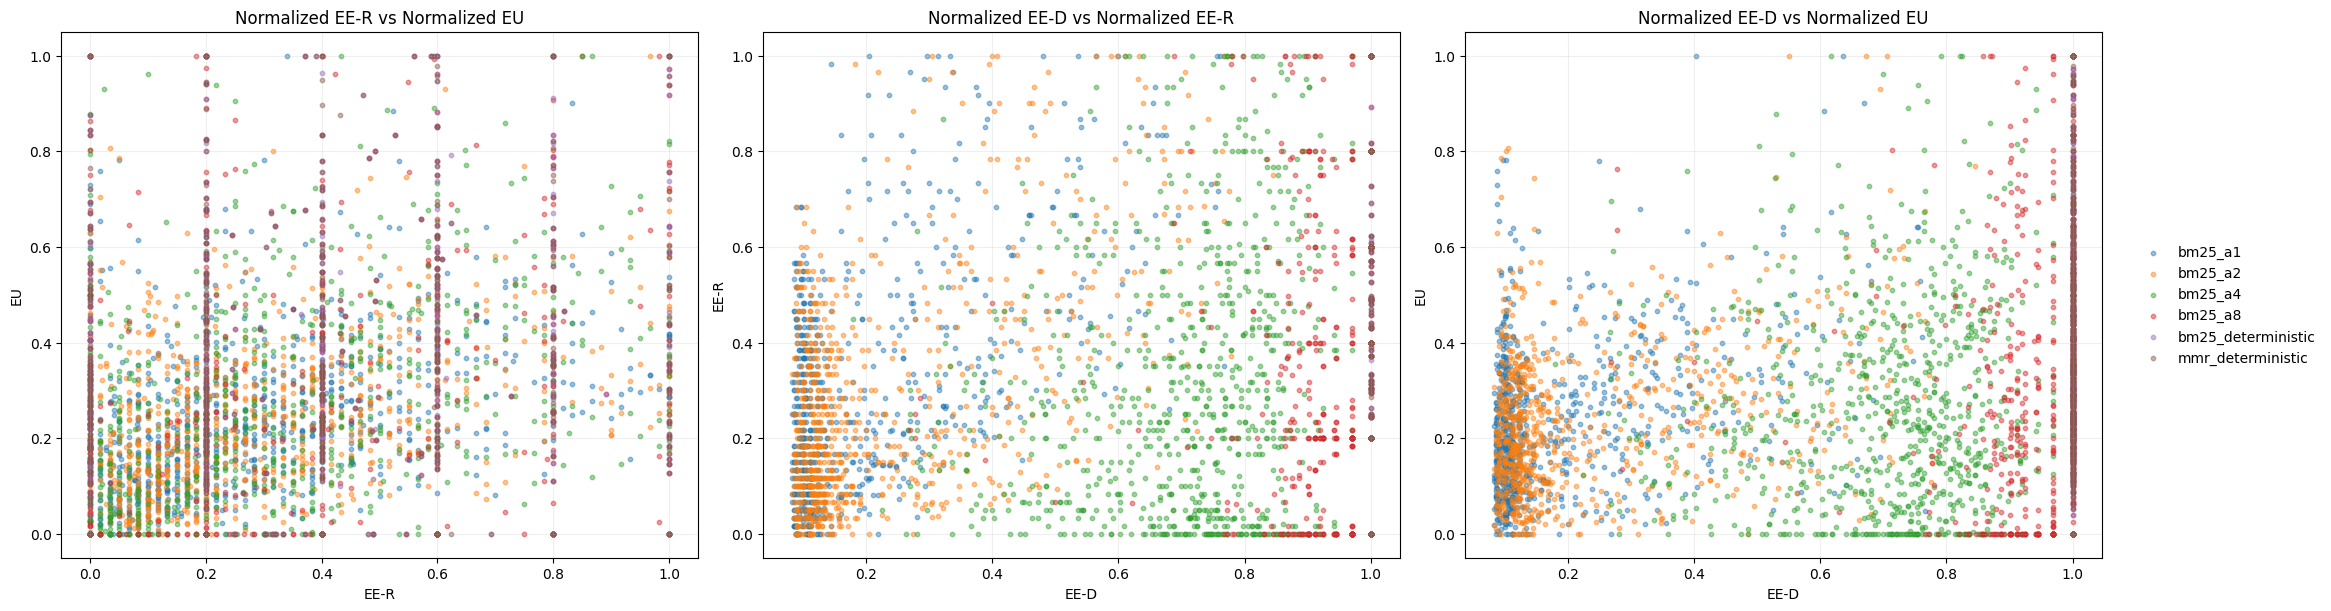

In [22]:
import matplotlib.pyplot as plt

# Keep this section non-destructive: never overwrite normalized outputs.
_prev_skip_existing = cfg.skip_existing
cfg.skip_existing = True

# Ensure deterministic normalized files exist (safe: skip if already present).
normalize_eu_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alpha=DETERMINISTIC_ALPHA,
    output_suffix='_deterministic',
)
normalize_eu_for_retriever(
    cfg,
    retriever_name='mmr',
    alpha=DETERMINISTIC_ALPHA,
    output_suffix='_mmr_deterministic',
)

# Load normalized data.
df_bm25_norm = load_normalized_rows(cfg).copy()
df_bm25_norm['series'] = df_bm25_norm['alpha'].map(lambda a: f'bm25_a{a}')

df_bm25_det_norm = load_normalized_rows_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()
df_bm25_det_norm['series'] = f'{cfg.retriever_name}_deterministic'

df_mmr_det_norm = load_normalized_rows_for_retriever(
    cfg,
    retriever_name='mmr',
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_mmr_deterministic',
).copy()
df_mmr_det_norm['series'] = 'mmr_deterministic'

df_plot = pd.concat([df_bm25_norm, df_bm25_det_norm, df_mmr_det_norm], ignore_index=True)

# Restore original setting for later cells.
cfg.skip_existing = _prev_skip_existing

print('Rows loaded for plotting:', len(df_plot))
print('Series:', sorted(df_plot['series'].unique()))

# Pairwise normalized plots requested by user.
pairs = [
    ('ee_r', 'eu', 'Normalized EE-R vs Normalized EU'),
    ('ee_d', 'ee_r', 'Normalized EE-D vs Normalized EE-R'),
    ('ee_d', 'eu', 'Normalized EE-D vs Normalized EU'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for ax, (x_col, y_col, title) in zip(axes, pairs):
    for series_name, g in df_plot.groupby('series', sort=True):
        ax.scatter(g[x_col], g[y_col], s=10, alpha=0.45, label=series_name)
    ax.set_xlabel(x_col.upper().replace('_', '-'))
    ax.set_ylabel(y_col.upper().replace('_', '-'))
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

# Keep legend outside so plots stay readable.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.show()

## Per-Alpha Mean Graphs (BM25 Only) + Normalized Settings Summary

This section:
- plots per-alpha averages for BM25 only (excludes gold and MMR from the plots)
- prints normalized EU summaries for BM25 alphas, deterministic BM25, deterministic MMR, and gold
- prints key experiment settings used in this notebook

[14:44:34] Start: per-alpha mean plots + normalized settings summary
[14:44:34] RUN_MISSING_NORMALIZATION=False
[14:44:34] Step 1: file presence check
[14:44:34] [exists] (required) bm25_alpha_1_normalized -> /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_normalized.json
[14:44:34] [exists] (required) bm25_alpha_2_normalized -> /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_2_normalized.json
[14:44:34] [exists] (required) bm25_alpha_4_normalized -> /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_4_normalized.json
[14:44:34] [exists] (required) bm25_alpha_8_normalized -> /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_8_normalized.json
[14:44:34] [exists] (optional) bm25_alpha_1_deterministic_normalized -> /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/alpha_1_deterministic_normalized.json
[14:44:34] [exists] (optional) mmr_alpha_1_mmr_deterministic_norma

,run,alpha,n_qids,mean_ee_d,mean_ee_r,mean_eu_normalized
0,bm25_deterministic,1,833,1.000000,0.315762,0.262936
1,bm25_stochastic,1,833,0.193321,0.284190,0.231760
2,bm25_stochastic,2,833,0.240523,0.288537,0.238560
3,bm25_stochastic,4,833,0.708750,0.310704,0.260776
4,bm25_stochastic,8,833,0.958577,0.314613,0.263201
5,mmr_deterministic,1,833,1.000000,0.310872,0.266538


[14:44:34] Step 5: BM25 per-alpha mean plots (+ deterministic as alpha=inf, same line)


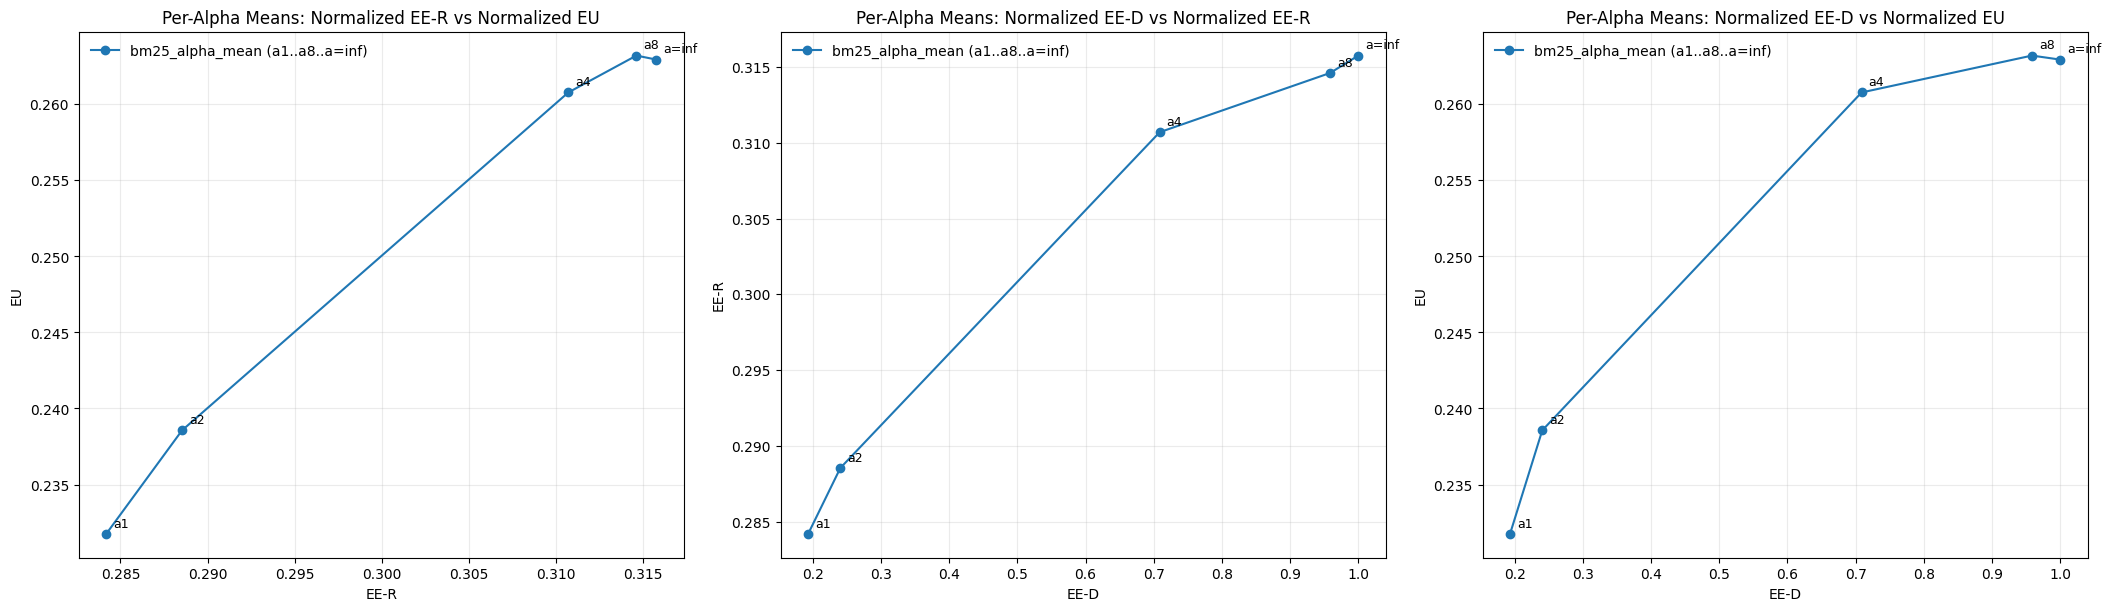

[14:44:34] Done


In [23]:
import time
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

# Keep False for fast, non-destructive behavior.
# If True, only missing normalized JSONs are generated (no overwrite).
RUN_MISSING_NORMALIZATION = False

def _ts() -> str:
    return datetime.now().strftime('%H:%M:%S')

def _status(msg: str) -> None:
    print(f"[{_ts()}] {msg}", flush=True)

def _normalized_fp(retriever_name: str, alpha: int, output_suffix: str = '') -> Path:
    suffix = output_suffix
    if suffix and not suffix.startswith('_'):
        suffix = f'_{suffix}'
    return (
        cfg.root
        / 'experiment_results'
        / cfg.generator_name
        / f'lamp{cfg.lamp_num}'
        / retriever_name
        / f'alpha_{alpha}{suffix}_normalized.json'
    )

_status('Start: per-alpha mean plots + normalized settings summary')
_status(f'RUN_MISSING_NORMALIZATION={RUN_MISSING_NORMALIZATION}')

required_files = []
# BM25 stochastic normalized files (REQUIRED for the per-alpha plots)
for alpha in cfg.alphas:
    required_files.append({
        'name': f'bm25_alpha_{alpha}_normalized',
        'retriever': cfg.retriever_name,
        'alpha': alpha,
        'suffix': '',
        'required': True,
        'fp': _normalized_fp(cfg.retriever_name, alpha, ''),
    })

# Optional for settings summary only
required_files.extend([
    {
        'name': f'bm25_alpha_{DETERMINISTIC_ALPHA}_deterministic_normalized',
        'retriever': cfg.retriever_name,
        'alpha': DETERMINISTIC_ALPHA,
        'suffix': '_deterministic',
        'required': False,
        'fp': _normalized_fp(cfg.retriever_name, DETERMINISTIC_ALPHA, '_deterministic'),
    },
    {
        'name': f'mmr_alpha_{DETERMINISTIC_ALPHA}_mmr_deterministic_normalized',
        'retriever': 'mmr',
        'alpha': DETERMINISTIC_ALPHA,
        'suffix': '_mmr_deterministic',
        'required': False,
        'fp': _normalized_fp('mmr', DETERMINISTIC_ALPHA, '_mmr_deterministic'),
    },
    {
        'name': f'gold_alpha_{SANITY_GOLD_ALPHA}_normalized',
        'retriever': 'gold',
        'alpha': SANITY_GOLD_ALPHA,
        'suffix': '',
        'required': False,
        'fp': _normalized_fp('gold', SANITY_GOLD_ALPHA, ''),
    },
])

_status('Step 1: file presence check')
missing = []
for item in required_files:
    exists = item['fp'].exists()
    state = 'exists' if exists else 'missing'
    req = 'required' if item['required'] else 'optional'
    _status(f"[{state}] ({req}) {item['name']} -> {item['fp']}")
    if not exists:
        missing.append(item)

if missing and RUN_MISSING_NORMALIZATION:
    _status(f'Step 2: normalizing {len(missing)} missing file(s) only (skip_existing=True)')
    _prev_skip_existing = cfg.skip_existing
    cfg.skip_existing = True
    try:
        for item in missing:
            _status(
                f"[run ] normalize retriever={item['retriever']} alpha={item['alpha']} suffix={item['suffix'] or 'plain'}"
            )
            t0 = time.time()
            normalize_eu_for_retriever(
                cfg,
                retriever_name=item['retriever'],
                alpha=item['alpha'],
                output_suffix=item['suffix'],
            )
            _status(f"[done] {item['name']} in {time.time() - t0:.1f}s")
    finally:
        cfg.skip_existing = _prev_skip_existing

# Recompute missing after optional normalization pass.
missing_now = [item for item in required_files if not item['fp'].exists()]
missing_required = [item for item in missing_now if item['required']]
missing_optional = [item for item in missing_now if not item['required']]

if missing_optional:
    _status('Optional normalized files still missing; they will be skipped in summary:')
    for item in missing_optional:
        _status(f"[skip] {item['name']}")

if missing_required:
    _status('Required BM25 normalized alpha files are missing; cannot build per-alpha plots.')
    _status('To auto-create missing files, set RUN_MISSING_NORMALIZATION=True and rerun this cell.')
    raise RuntimeError(f"Missing required files: {[x['name'] for x in missing_required]}")

_status('Step 3: load normalized dataframes')
t0_load = time.time()

bm25_norm = load_normalized_rows(cfg).copy()
bm25_mean = (
    bm25_norm.groupby('alpha', as_index=False)
    .agg(
        n_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu=('eu', 'mean'),
    )
    .sort_values('alpha')
    .reset_index(drop=True)
)

# Optional summary components: load only if file exists.
bm25_det_norm = None
mmr_det_norm = None
gold_norm = None

bm25_det_fp = _normalized_fp(cfg.retriever_name, DETERMINISTIC_ALPHA, '_deterministic')
if bm25_det_fp.exists():
    bm25_det_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name=cfg.retriever_name,
        alphas=(DETERMINISTIC_ALPHA,),
        output_suffix='_deterministic',
    )

mmr_det_fp = _normalized_fp('mmr', DETERMINISTIC_ALPHA, '_mmr_deterministic')
if mmr_det_fp.exists():
    mmr_det_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name='mmr',
        alphas=(DETERMINISTIC_ALPHA,),
        output_suffix='_mmr_deterministic',
    )

gold_fp = _normalized_fp('gold', SANITY_GOLD_ALPHA, '')
if gold_fp.exists():
    gold_norm = load_normalized_rows_for_retriever(
        cfg,
        retriever_name='gold',
        alphas=(SANITY_GOLD_ALPHA,),
        output_suffix='',
    )

_status(f'Step 3 complete in {time.time()-t0_load:.1f}s')

def _mean_row(df, label, alpha):
    return {
        'run': label,
        'alpha': alpha,
        'n_qids': int(df['qid'].nunique()),
        'mean_ee_d': float(df['ee_d'].mean()),
        'mean_ee_r': float(df['ee_r'].mean()),
        'mean_eu_normalized': float(df['eu'].mean()),
    }

summary_rows = []
for _, r in bm25_mean.iterrows():
    summary_rows.append({
        'run': 'bm25_stochastic',
        'alpha': int(r['alpha']),
        'n_qids': int(r['n_qids']),
        'mean_ee_d': float(r['mean_ee_d']),
        'mean_ee_r': float(r['mean_ee_r']),
        'mean_eu_normalized': float(r['mean_eu']),
    })

if bm25_det_norm is not None:
    summary_rows.append(_mean_row(bm25_det_norm, 'bm25_deterministic', DETERMINISTIC_ALPHA))
else:
    _status('Summary skip: bm25_deterministic normalized file missing')

if mmr_det_norm is not None:
    summary_rows.append(_mean_row(mmr_det_norm, 'mmr_deterministic', DETERMINISTIC_ALPHA))
else:
    _status('Summary skip: mmr_deterministic normalized file missing')

if gold_norm is not None:
    summary_rows.append(_mean_row(gold_norm, 'gold', SANITY_GOLD_ALPHA))
else:
    _status('Summary skip: gold normalized file missing')

normalized_summary = pd.DataFrame(summary_rows).sort_values(['run', 'alpha']).reset_index(drop=True)

_status('Step 4: print settings + normalized summary')
print('profile_name          =', profile_name)
print('retriever             =', cfg.retriever_name)
print('generator             =', cfg.generator_name)
print('lamp_num              =', cfg.lamp_num)
print('all_alphas            =', cfg.alphas)
print('deterministic_alpha   =', DETERMINISTIC_ALPHA)
print('gold_alpha            =', SANITY_GOLD_ALPHA)
print('mmr_lambdas           =', MMR_LAMBDAS)
print('run flags:')
print(' RUN_GOLD              =', RUN_GOLD)
print(' RUN_DETERMINISTIC_REF =', RUN_DETERMINISTIC_REF)
print(' RUN_MMR_DETERMINISTIC =', RUN_MMR_DETERMINISTIC)
print(' RUN_MMR_LAMBDA_SWEEP  =', RUN_MMR_LAMBDA_SWEEP)
print(' RUN_BM25_GRID         =', RUN_BM25_GRID)
print(' RUN_NORMALIZE_EU      =', RUN_NORMALIZE_EU)
print(' RUN_SANITY            =', RUN_SANITY)
print(' RUN_ANALYSIS          =', RUN_ANALYSIS)

print('\nNormalized Summary (available runs):')
display(normalized_summary)

_status('Step 5: BM25 per-alpha mean plots (+ deterministic as alpha=inf, same line)')
pair_specs = [
    ('mean_ee_r', 'mean_eu', 'Per-Alpha Means: Normalized EE-R vs Normalized EU'),
    ('mean_ee_d', 'mean_ee_r', 'Per-Alpha Means: Normalized EE-D vs Normalized EE-R'),
    ('mean_ee_d', 'mean_eu', 'Per-Alpha Means: Normalized EE-D vs Normalized EU'),
]

# Aggregate deterministic BM25 point once so we can append it to the same polyline.
bm25_det_point = None
if bm25_det_norm is not None:
    bm25_det_point = {
        'mean_ee_d': float(bm25_det_norm['ee_d'].mean()),
        'mean_ee_r': float(bm25_det_norm['ee_r'].mean()),
        'mean_eu': float(bm25_det_norm['eu'].mean()),
    }

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for ax, (x_col, y_col, title) in zip(axes, pair_specs):
    x_vals = bm25_mean[x_col].tolist()
    y_vals = bm25_mean[y_col].tolist()
    point_labels = [f"a{int(a)}" for a in bm25_mean['alpha'].tolist()]

    if bm25_det_point is not None:
        x_vals.append(bm25_det_point[x_col])
        y_vals.append(bm25_det_point[y_col])
        point_labels.append('a=inf')

    # Single BM25 line including deterministic point as alpha=inf.
    ax.plot(
        x_vals,
        y_vals,
        '-o',
        linewidth=1.5,
        markersize=6,
        label='bm25_alpha_mean (a1..a8..a=inf)' if bm25_det_point is not None else 'bm25_alpha_mean (finite alpha)',
    )

    for x, y, lbl in zip(x_vals, y_vals, point_labels):
        ax.annotate(
            lbl,
            (x, y),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
        )

    ax.set_xlabel(x_col.replace('mean_', '').upper().replace('_', '-'))
    ax.set_ylabel(y_col.replace('mean_', '').upper().replace('_', '-'))
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

plt.show()
_status('Done')

## Interval Tables (Normalized)

This section builds:
- Table A: normalized EU by EE-D disparity interval
- Table B (Table-2 style): normalized EU difference (stochastic - deterministic) by EE-D interval

In [24]:
import pandas as pd

print('Building normalized interval tables (pooled across alphas)...')

# Load normalized stochastic BM25 (all configured alphas).
df_st = load_normalized_rows(cfg).copy()

# Load normalized deterministic BM25 (alpha=1 deterministic file).
df_det = load_normalized_rows_for_retriever(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()

# Half-open disparity intervals requested by user: [0.0-0.2), [0.2-0.4), ...
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
labels = ['[0.0-0.2)', '[0.2-0.4)', '[0.4-0.6)', '[0.6-0.8)', '[0.8-1.0]']

df_st['ee_d_interval'] = pd.cut(
    df_st['ee_d'], bins=bins, labels=labels, include_lowest=True, right=False
)

# --- Table A: normalized EU by disparity interval (pooled across alphas) ---
table_a = (
    df_st.groupby('ee_d_interval', observed=False)
    .agg(
        n_rows=('qid', 'count'),
        n_unique_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu=('eu', 'mean'),
    )
    .reset_index()
    .sort_values('ee_d_interval')
    .reset_index(drop=True)
)

print('\nTable A: Normalized EU by EE-D disparity interval (pooled over all alphas)')
display(table_a)

# --- Table B: Table-2 style EU deltas (stochastic - deterministic) by interval ---
# Bin by stochastic EE-D interval, then compare EU on same qids against deterministic.
det_eu_by_qid = df_det.groupby('qid', as_index=False)['eu'].mean().rename(columns={'eu': 'eu_det'})

table_b_rows = []
for interval in labels:
    st_slice = df_st[df_st['ee_d_interval'].astype(str) == interval][['qid', 'eu', 'ee_d', 'ee_r']].copy()

    if st_slice.empty:
        table_b_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic': float('nan'),
            'mean_eu_deterministic': float('nan'),
            'eu_diff_st_minus_det': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    # Multiple rows per qid may exist (from different alphas).
    # Keep one stochastic value per qid by averaging across its stochastic rows in this interval.
    st_by_qid = (
        st_slice.groupby('qid', as_index=False)
        .agg(
            eu=('eu', 'mean'),
            ee_d=('ee_d', 'mean'),
            ee_r=('ee_r', 'mean'),
        )
    )

    paired = st_by_qid.merge(det_eu_by_qid, on='qid', how='inner')
    n_qids = paired['qid'].nunique()

    if n_qids == 0:
        table_b_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic': float('nan'),
            'mean_eu_deterministic': float('nan'),
            'eu_diff_st_minus_det': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    mean_st = float(paired['eu'].mean())
    mean_det = float(paired['eu_det'].mean())
    table_b_rows.append({
        'ee_d_interval': interval,
        'n_qids': int(n_qids),
        'mean_eu_stochastic': mean_st,
        'mean_eu_deterministic': mean_det,
        'eu_diff_st_minus_det': mean_st - mean_det,
        'mean_ee_d_stochastic': float(paired['ee_d'].mean()),
        'mean_ee_r_stochastic': float(paired['ee_r'].mean()),
    })

table_b = pd.DataFrame(table_b_rows).sort_values('ee_d_interval').reset_index(drop=True)

print('\nTable B (Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)')
display(table_b)

# Save interval-only tables.
out_dir = (
    cfg.root
    / 'experiment_results'
    / cfg.generator_name
    / f'lamp{cfg.lamp_num}'
    / cfg.retriever_name
    / f'notebook_outputs_{profile_name}'
)
out_dir.mkdir(parents=True, exist_ok=True)
table_a_fp = out_dir / 'tableA_normalized_eu_by_disparity_interval_pooled.csv'
table_b_fp = out_dir / 'tableB_eu_diff_st_minus_det_by_disparity_interval_pooled.csv'
table_a.to_csv(table_a_fp, index=False)
table_b.to_csv(table_b_fp, index=False)

print('\nSaved tables:')
print(' -', table_a_fp)
print(' -', table_b_fp)

Building normalized interval tables (pooled across alphas)...

Table A: Normalized EU by EE-D disparity interval (pooled over all alphas)


,ee_d_interval,n_rows,n_unique_qids,mean_ee_d,mean_ee_r,mean_eu
0,[0.0-0.2),1106,581,0.118789,0.207468,0.202365
1,[0.2-0.4),350,259,0.295960,0.338559,0.262007
2,[0.4-0.6),316,275,0.499481,0.384886,0.286543
3,[0.6-0.8),497,452,0.710843,0.357234,0.276237
4,[0.8-1.0],1063,804,0.944669,0.330053,0.268009



Table B (Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)


,ee_d_interval,n_qids,mean_eu_stochastic,mean_eu_deterministic,eu_diff_st_minus_det,mean_ee_d_stochastic,mean_ee_r_stochastic
0,[0.0-0.2),581,0.201334,0.236925,-0.035591,0.121214,0.209077
1,[0.2-0.4),259,0.255703,0.270756,-0.015053,0.298654,0.337426
2,[0.4-0.6),275,0.279792,0.290434,-0.010642,0.499675,0.370179
3,[0.6-0.8),452,0.261184,0.257973,0.003212,0.711835,0.319770
4,[0.8-1.0],804,0.260613,0.260430,0.000184,0.950623,0.313180



Saved tables:
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableA_normalized_eu_by_disparity_interval_pooled.csv
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableB_eu_diff_st_minus_det_by_disparity_interval_pooled.csv


## Interval Tables (Raw EU, Non-Normalized)

Same pooled interval analysis as above, but using non-normalized EU from raw experiment outputs.

In [12]:
import pandas as pd

print('Building raw-EU interval tables (pooled across alphas)...')

# Load RAW stochastic BM25 (all configured alphas).
df_st_raw = load_raw_rows(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=cfg.alphas,
    output_suffix='',
).copy()

# Load RAW deterministic BM25 (alpha=1 deterministic file).
df_det_raw = load_raw_rows(
    cfg,
    retriever_name=cfg.retriever_name,
    alphas=(DETERMINISTIC_ALPHA,),
    output_suffix='_deterministic',
).copy()

# Same half-open disparity intervals: [0.0-0.2), [0.2-0.4), ...
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
labels = ['[0.0-0.2)', '[0.2-0.4)', '[0.4-0.6)', '[0.6-0.8)', '[0.8-1.0]']

df_st_raw['ee_d_interval'] = pd.cut(
    df_st_raw['ee_d'], bins=bins, labels=labels, include_lowest=True, right=False
)

# --- Table A (RAW): EU by disparity interval (pooled across alphas) ---
table_a_raw = (
    df_st_raw.groupby('ee_d_interval', observed=False)
    .agg(
        n_rows=('qid', 'count'),
        n_unique_qids=('qid', 'nunique'),
        mean_ee_d=('ee_d', 'mean'),
        mean_ee_r=('ee_r', 'mean'),
        mean_eu_raw=('eu', 'mean'),
    )
    .reset_index()
    .sort_values('ee_d_interval')
    .reset_index(drop=True)
)

print('\nTable A (RAW): EU by EE-D disparity interval (pooled over all alphas)')
display(table_a_raw)

# --- Table B (RAW): Table-2 style EU deltas (stochastic - deterministic) by interval ---
det_eu_by_qid_raw = df_det_raw.groupby('qid', as_index=False)['eu'].mean().rename(columns={'eu': 'eu_det_raw'})

table_b_raw_rows = []
for interval in labels:
    st_slice = df_st_raw[df_st_raw['ee_d_interval'].astype(str) == interval][['qid', 'eu', 'ee_d', 'ee_r']].copy()

    if st_slice.empty:
        table_b_raw_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic_raw': float('nan'),
            'mean_eu_deterministic_raw': float('nan'),
            'eu_diff_st_minus_det_raw': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    # Multiple rows per qid may exist (from different alphas).
    # Keep one stochastic value per qid by averaging across its stochastic rows in this interval.
    st_by_qid = (
        st_slice.groupby('qid', as_index=False)
        .agg(
            eu=('eu', 'mean'),
            ee_d=('ee_d', 'mean'),
            ee_r=('ee_r', 'mean'),
        )
    )

    paired = st_by_qid.merge(det_eu_by_qid_raw, on='qid', how='inner')
    n_qids = paired['qid'].nunique()

    if n_qids == 0:
        table_b_raw_rows.append({
            'ee_d_interval': interval,
            'n_qids': 0,
            'mean_eu_stochastic_raw': float('nan'),
            'mean_eu_deterministic_raw': float('nan'),
            'eu_diff_st_minus_det_raw': float('nan'),
            'mean_ee_d_stochastic': float('nan'),
            'mean_ee_r_stochastic': float('nan'),
        })
        continue

    mean_st = float(paired['eu'].mean())
    mean_det = float(paired['eu_det_raw'].mean())
    table_b_raw_rows.append({
        'ee_d_interval': interval,
        'n_qids': int(n_qids),
        'mean_eu_stochastic_raw': mean_st,
        'mean_eu_deterministic_raw': mean_det,
        'eu_diff_st_minus_det_raw': mean_st - mean_det,
        'mean_ee_d_stochastic': float(paired['ee_d'].mean()),
        'mean_ee_r_stochastic': float(paired['ee_r'].mean()),
    })

table_b_raw = pd.DataFrame(table_b_raw_rows).sort_values('ee_d_interval').reset_index(drop=True)

print('\nTable B (RAW, Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)')
display(table_b_raw)

# Save raw interval-only tables next to normalized outputs.
out_dir = (
    cfg.root
    / 'experiment_results'
    / cfg.generator_name
    / f'lamp{cfg.lamp_num}'
    / cfg.retriever_name
    / f'notebook_outputs_{profile_name}'
)
out_dir.mkdir(parents=True, exist_ok=True)
table_a_raw_fp = out_dir / 'tableA_raw_eu_by_disparity_interval_pooled.csv'
table_b_raw_fp = out_dir / 'tableB_raw_eu_diff_st_minus_det_by_disparity_interval_pooled.csv'
table_a_raw.to_csv(table_a_raw_fp, index=False)
table_b_raw.to_csv(table_b_raw_fp, index=False)

print('\nSaved raw tables:')
print(' -', table_a_raw_fp)
print(' -', table_b_raw_fp)

Building raw-EU interval tables (pooled across alphas)...

Table A (RAW): EU by EE-D disparity interval (pooled over all alphas)


,ee_d_interval,n_rows,n_unique_qids,mean_ee_d,mean_ee_r,mean_eu_raw
0,[0.0-0.2),1106,581,0.118789,0.207468,0.032586
1,[0.2-0.4),350,259,0.295960,0.338559,0.054542
2,[0.4-0.6),316,275,0.499481,0.384886,0.049643
3,[0.6-0.8),497,452,0.710843,0.357234,0.050271
4,[0.8-1.0],1063,804,0.944669,0.330053,0.048820



Table B (RAW, Table-2 style): EU difference by stochastic EE-D interval (pooled over all alphas)


,ee_d_interval,n_qids,mean_eu_stochastic_raw,mean_eu_deterministic_raw,eu_diff_st_minus_det_raw,mean_ee_d_stochastic,mean_ee_r_stochastic
0,[0.0-0.2),581,0.032601,0.042184,-0.009584,0.121214,0.209077
1,[0.2-0.4),259,0.051992,0.055496,-0.003504,0.298654,0.337426
2,[0.4-0.6),275,0.049057,0.053525,-0.004468,0.499675,0.370179
3,[0.6-0.8),452,0.047974,0.047033,0.000941,0.711835,0.319770
4,[0.8-1.0],804,0.047702,0.047482,0.000220,0.950623,0.313180



Saved raw tables:
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableA_raw_eu_by_disparity_interval_pooled.csv
 - /Users/asimk/Code/Fair-RAG/experiment_results/flanT5Small/lamp4/bm25/notebook_outputs_balanced/tableB_raw_eu_diff_st_minus_det_by_disparity_interval_pooled.csv


In [ ]:
# Force a true balanced rerun (833 queries) instead of reusing existing weak outputs.
cfg.skip_existing = False
FORCE_FRESH_RUN = True

print('Forced rerun settings:')
print(' profile_name      =', profile_name)
print(' cfg.max_queries   =', cfg.max_queries)
print(' cfg.skip_existing =', cfg.skip_existing)
print(' FORCE_FRESH_RUN   =', FORCE_FRESH_RUN)
print(' MMR_LAMBDAS       =', MMR_LAMBDAS)

Current deterministic MMR lambda sweep summary (raw EU and EE-R):


,mmr_lambda,n_qids,mean_ee_r,mean_eu
0,0.0,30,0.113333,0.015120
1,0.1,30,0.133333,0.019047
2,0.2,30,0.173333,0.013905
3,0.3,30,0.169362,0.020878
4,0.4,30,0.169362,0.025200
5,0.5,30,0.176028,0.022288
6,0.6,30,0.176028,0.025545
7,0.7,30,0.189362,0.024094
8,0.8,30,0.182695,0.021256
9,0.9,30,0.182695,0.021184


In [27]:
# ===== Run Status Inspector =====
# Shows the latest N runs: status (completed / interrupted), config, and metrics.
#
# To RESUME an interrupted run:
#   1. Make sure FORCE_FRESH_RUN = False (Cell 4)
#   2. Re-run Cells 1-2 (imports) and Cell 5 (pipeline)
#   The checkpoint is auto-detected and the run continues from where it left off.

from pathlib import Path
import json
import pandas as pd

# ---------- Config ----------
N_RECENT_RUNS = 5      # how many recent runs to list (newest first); 1 = latest only
RUN_TAG_FILTER = None  # narrow by tag, e.g. "balanced", "weak", or None for all
# ----------------------------

try:
    _runs_dir = ROOT / "experiment_results" / "runs"
except NameError:
    _runs_dir = Path("experiment_results/runs").resolve()

if not _runs_dir.exists() or not any(_runs_dir.iterdir()):
    print("No runs found yet. Run the pipeline (Cell 5) first.")
else:
    _all_runs = sorted(
        [d for d in _runs_dir.iterdir() if d.is_dir()],
        key=lambda d: d.name,
        reverse=True,
    )
    if RUN_TAG_FILTER:
        _all_runs = [d for d in _all_runs if RUN_TAG_FILTER in d.name]

    _runs_to_show = _all_runs[:N_RECENT_RUNS]
    print(f"Total runs found : {len(_all_runs)}")
    if RUN_TAG_FILTER:
        print(f"Tag filter       : '{RUN_TAG_FILTER}'")
    print(f"Showing latest   : {len(_runs_to_show)}\n")

    for _run_dir in _runs_to_show:
        _params_fp  = _run_dir / "params.json"
        _progress_fp = _run_dir / "progress.csv"

        if not _params_fp.exists():
            print(f"  {_run_dir.name}  [no params.json — skipping]\n")
            continue

        _p       = json.loads(_params_fp.read_text())
        _is_done = bool(_p.get("completed_at"))
        _status  = "COMPLETED" if _is_done else "INTERRUPTED / IN PROGRESS"

        print("=" * 70)
        print(f"  {_run_dir.name}")
        print(f"  Status    : {_status}")
        print(f"  Started   : {_p.get('started_at', '?')}")
        if _is_done:
            print(f"  Finished  : {_p.get('completed_at', '?')}")
        print(
            f"  Config    : retriever={_p.get('retriever','?')} | alpha={_p.get('alpha','?')}"
            f" | suffix={_p.get('output_suffix') or '(none)'}"
            f" | n_samples={_p.get('n_samples','?')}"
            f" | max_queries={_p.get('max_queries','?')}"
            f" | tag={_p.get('run_tag') or '(none)'}"
        )
        if _p.get("mmr_lambda") is not None:
            print(f"  MMR lambda: {_p['mmr_lambda']}")

        # --- Progress ---
        if _progress_fp.exists():
            _df = pd.read_csv(_progress_fp)
            if not _df.empty:
                _last      = _df.iloc[-1]
                _processed = int(_last["query_count"])
                _total_raw = _last["total_queries"]
                try:
                    _total_int = int(_total_raw)
                    _total_str = str(_total_int)
                    _pct_str   = f"{100.0 * _processed / _total_int:.0f}%"
                except (ValueError, TypeError):
                    _total_str = "?"
                    _pct_str   = "?"
                print(f"  Progress  : {_processed} / {_total_str} queries ({_pct_str})")
                print(
                    f"  Last avg  :"
                    f"  EE-D={float(_last['mean_ee_d']):.4f}"
                    f"  EE-R={float(_last['mean_ee_r']):.4f}"
                    f"  EU={float(_last['mean_eu']):.4f}"
                )
                if len(_df) > 1:
                    _disp = _df[["timestamp", "query_count", "total_queries",
                                 "mean_ee_d", "mean_ee_r", "mean_eu"]].copy()
                    _disp.columns = ["timestamp", "q_done", "q_total", "EE-D", "EE-R", "EU"]
                    print(f"\n  Progress log ({len(_df)} checkpoints):")
                    print(_disp.to_string(index=False, float_format="{:.4f}".format))
            else:
                print("  Progress  : progress.csv is empty")
        else:
            print("  Progress  : no progress.csv (run killed before first checkpoint)")

        # --- Output / checkpoint files ---
        _out_fp_str = _p.get("output_file")
        if _out_fp_str:
            _out_fp  = Path(_out_fp_str)
            _ckpt_fp = Path(_out_fp_str[:-5] + "_ckpt.json")
            print(f"  Output    : {'EXISTS' if _out_fp.exists() else 'MISSING'} — {_out_fp.name}")
            print(
                f"  Checkpoint: {'EXISTS (resume ready)' if _ckpt_fp.exists() else 'not present'}"
                f" — {_ckpt_fp.name}"
            )

        # --- Resume / restart guidance ---
        if not _is_done:
            print()
            if _out_fp_str:
                _ckpt_fp = Path(_out_fp_str[:-5] + "_ckpt.json")
                if _ckpt_fp.exists():
                    _ckpt_count = len(json.loads(_ckpt_fp.read_text()).get("results", {}))
                    print(f"  >> RESUME : checkpoint has {_ckpt_count} queries saved.")
                    print(f"     Keep FORCE_FRESH_RUN = False, then re-run Cells 1-2 and Cell 5.")
                    print(f"     The run will skip {_ckpt_count} already-processed queries.")
                else:
                    print(f"  >> RESTART: no checkpoint found — run will start from scratch.")
                    print(f"     Keep FORCE_FRESH_RUN = False and re-run Cells 1-2 and Cell 5.")

        print()


Total runs found : 61
Showing latest   : 5

  20260329_204541_gold_alpha1_mmr-on-gold-deterministic_flanT5Small_lamp4_nq833_balanced
  Status    : INTERRUPTED / IN PROGRESS
  Started   : 2026-03-29T20:45:41
  Config    : retriever=mmr | alpha=1 | suffix=_mmr_on_gold_deterministic | n_samples=1 | max_queries=833 | tag=balanced
  MMR lambda: 0.6
  Progress  : 170 / 833 queries (20%)
  Last avg  :  EE-D=1.0000  EE-R=0.9901  EU=0.0801

  Progress log (4 checkpoints):
          timestamp  q_done  q_total   EE-D   EE-R     EU
2026-03-29T20:54:45     140      833 1.0000 0.9880 0.0827
2026-03-29T21:03:51     150      833 1.0000 0.9888 0.0824
2026-03-29T21:12:51     160      833 1.0000 0.9895 0.0806
2026-03-29T21:22:00     170      833 1.0000 0.9901 0.0801
  Output    : MISSING — alpha_1_mmr_on_gold_deterministic.json
  Checkpoint: EXISTS (resume ready) — alpha_1_mmr_on_gold_deterministic_ckpt.json

  >> RESUME : checkpoint has 170 queries saved.
     Keep FORCE_FRESH_RUN = False, then re-run C

In [10]:
# Targeted rerun helper with two detectors:
# 1) degenerate retriever-score qids (pre-run signal)
# 2) invalid-result qids from existing outputs (post-run signal: NaN/inf/non-numeric EE/EU)

AUTO_DISCOVER_QIDS = True
TARGET_QIDS = []  # Optional manual additions.
TARGET_ALPHAS = cfg.alphas  # e.g., (1, 2, 4, 8)
SPLIT_TYPE = 'user'

if AUTO_DISCOVER_QIDS:
    score_qids = find_degenerate_score_qids(
        cfg,
        retriever_name=cfg.retriever_name,
        split_type=SPLIT_TYPE,
        max_queries=cfg.max_queries,
    )
    invalid_qids = find_invalid_result_qids(
        cfg,
        retriever_name=cfg.retriever_name,
        alphas=TARGET_ALPHAS,
        output_suffix='',
    )
else:
    score_qids = []
    invalid_qids = []

qids = sorted(
    set(score_qids + invalid_qids + [str(q).strip() for q in TARGET_QIDS if str(q).strip()])
)

print(f'Auto-detected score-degenerate qids: {len(score_qids)}')
print(f'Auto-detected invalid-result qids: {len(invalid_qids)}')
if qids:
    preview = ', '.join(qids[:10])
    print('Will recompute qids:', preview + (' ...' if len(qids) > 10 else ''))
else:
    print('No target qids found. Nothing to recompute.')
    print('If you still want to rerun specific qids, add them in TARGET_QIDS manually.')

if qids:
    for alpha in TARGET_ALPHAS:
        print(f'\n[targeted] recomputing alpha={alpha} for {len(qids)} qids')
        run_targeted_qids_for_alpha(
            cfg,
            retriever_name=cfg.retriever_name,
            alpha=alpha,
            qids=qids,
            deterministic_ranking=False,
            output_suffix='',
            recompute_target_qids=True,
        )

    print('\nDone: targeted recompute finished for BM25 alpha grid.')

Auto-detected score-degenerate qids: 0
Auto-detected invalid-result qids: 0
No target qids found. Nothing to recompute.
If you still want to rerun specific qids, add them in TARGET_QIDS manually.


In [15]:
import json
import re
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(cfg.root))
from perturbation import plackettluce as pl

# ── Settings ───────────────────────────────────────────────────────────────────
TOP_K = 5
MAX_QUERIES_DIVERSITY = None   # keep small on purpose; set None to use all queries
N_PL_SAMPLES = cfg.n_samples  # PL samples per query per alpha (12 for balanced)
SPLIT_TYPE_DIVERSITY = "user"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_MAX_LENGTH = 256
EMBEDDING_BATCH_SIZE = 64


# ── Helpers ────────────────────────────────────────────────────────────────────
def _tokenize(text: str) -> set:
    return set(re.findall(r"\w+", text.lower()))


def _profile_text(profile: dict) -> str:
    return " ".join(v for k, v in profile.items() if k != "id" and isinstance(v, str))


def _jaccard_dist(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return 1.0 - len(a & b) / len(a | b)


def _jaccard_sim(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


def _mean_pairwise_jd(token_sets: list) -> float:
    if len(token_sets) < 2:
        return float("nan")
    return float(np.mean([_jaccard_dist(a, b) for a, b in combinations(token_sets, 2)]))


def _mean_pairwise_ild(vectors: np.ndarray) -> float:
    if vectors.shape[0] < 2:
        return float("nan")
    sims = vectors @ vectors.T
    dists = 1.0 - sims
    iu = np.triu_indices(vectors.shape[0], k=1)
    return float(np.mean(dists[iu]))


def _tsets(pids: list, profile_by_pid: dict) -> list:
    return [_tokenize(_profile_text(profile_by_pid[p])) if p in profile_by_pid else set() for p in pids]


def _vectors_for_pids(pids: list, profile_by_pid: dict, text_vector_cache: dict, dim: int) -> np.ndarray:
    vectors = []
    for pid in pids:
        profile = profile_by_pid.get(pid, {})
        text = _profile_text(profile)
        vectors.append(text_vector_cache.get(text, np.zeros(dim, dtype=np.float32)))
    mat = np.asarray(vectors, dtype=np.float32)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    return mat / norms


def _metric_pair(pids: list, profile_by_pid: dict, text_vector_cache: dict, dim: int) -> tuple[float, float]:
    token_sets = _tsets(pids, profile_by_pid)
    vectors = _vectors_for_pids(pids, profile_by_pid, text_vector_cache, dim)
    return _mean_pairwise_jd(token_sets), _mean_pairwise_ild(vectors)


def _mmr_topk(retrieved: list, profile_by_pid: dict, mmr_lambda: float, k: int) -> list:
    if not retrieved:
        return retrieved
    mmr_lambda = float(min(1.0, max(0.0, mmr_lambda)))
    pids = [str(r[0]) for r in retrieved]
    scores = np.array([float(r[1]) for r in retrieved], dtype=float)
    s_min, s_max = scores.min(), scores.max()
    rel = (scores - s_min) / (s_max - s_min) if s_max > s_min else np.ones_like(scores)
    doc_toks = [_tokenize(_profile_text(profile_by_pid.get(p, {}))) for p in pids]
    selected, remaining = [], set(range(len(pids)))
    while remaining and len(selected) < k:
        best_idx, best_score = None, None
        for idx in remaining:
            pen = max((_jaccard_sim(doc_toks[idx], doc_toks[s]) for s in selected), default=0.0)
            score = mmr_lambda * float(rel[idx]) - (1 - mmr_lambda) * pen
            if best_score is None or score > best_score:
                best_score, best_idx = score, idx
        selected.append(best_idx)
        remaining.remove(best_idx)
    return [retrieved[i] for i in selected]


def _normalize_bm25_scores(raw_scores: np.ndarray, alpha: int) -> np.ndarray:
    scores = raw_scores.astype(float, copy=True)
    min_v = float(scores.min())
    if min_v < 0:
        scores = scores - min_v
    min_v, max_v = float(scores.min()), float(scores.max())
    denom = max_v - min_v
    if not np.isfinite(denom) or denom <= 0:
        scores = np.ones_like(scores)
    else:
        scores = (scores - min_v) / denom
    return (scores + 1.0) ** alpha  # [1,2]^alpha, matches experiment.py


def _pl_metric_pair(retrieved: list, profile_by_pid: dict, alpha: int, k: int, n_samples: int,
                    text_vector_cache: dict, dim: int) -> tuple[float, float]:
    pids_all = [str(r[0]) for r in retrieved]
    raw_scores = np.array([float(r[1]) for r in retrieved], dtype=float)
    scores = _normalize_bm25_scores(raw_scores, alpha)
    sampled_rankings = pl.gumbel_sample_rankings(scores, n_samples, cutoff=k, doc_prob=False)[0]

    jaccard_scores = []
    ild_scores = []
    for ranking in sampled_rankings:
        topk_pids = [pids_all[i] for i in ranking]
        jd, ild = _metric_pair(topk_pids, profile_by_pid, text_vector_cache, dim)
        jaccard_scores.append(jd)
        ild_scores.append(ild)
    return float(np.nanmean(jaccard_scores)), float(np.nanmean(ild_scores))


def _load_json(fp: Path) -> dict:
    with fp.open("r", encoding="utf-8") as f:
        return json.load(f)


def _choose_embedding_device() -> str:
    if torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def _build_text_vector_cache(texts: list[str]) -> tuple[dict, int, str]:
    unique_texts = list(dict.fromkeys(texts))
    if not unique_texts:
        return {}, 1, "none"

    try:
        from transformers import AutoModel, AutoTokenizer

        device = _choose_embedding_device()
        tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
        model = AutoModel.from_pretrained(EMBEDDING_MODEL_NAME)
        model = model.to(device)
        model.eval()

        all_embeddings = []
        for start in range(0, len(unique_texts), EMBEDDING_BATCH_SIZE):
            batch_texts = unique_texts[start:start + EMBEDDING_BATCH_SIZE]
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=EMBEDDING_MAX_LENGTH,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            with torch.no_grad():
                output = model(**encoded)
                sent = _mean_pool(output.last_hidden_state, encoded["attention_mask"])
                sent = torch.nn.functional.normalize(sent, p=2, dim=1)
            all_embeddings.append(sent.detach().cpu().numpy().astype(np.float32))
        embeddings = np.vstack(all_embeddings)
        return dict(zip(unique_texts, embeddings)), int(embeddings.shape[1]), f"Transformers[{EMBEDDING_MODEL_NAME}] on {device}"
    except Exception as exc:
        print(f"Dense embedding load failed; falling back to TF-IDF cosine ILD. Reason: {exc}")
        from sklearn.feature_extraction.text import TfidfVectorizer

        tfidf = TfidfVectorizer(lowercase=True, stop_words="english")
        matrix = tfidf.fit_transform(unique_texts).astype(np.float32)
        embeddings = matrix.toarray()
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms = np.where(norms > 0, norms, 1.0)
        embeddings = embeddings / norms
        return dict(zip(unique_texts, embeddings)), int(embeddings.shape[1]), "TF-IDF cosine fallback"


# ── Load shared data ───────────────────────────────────────────────────────────
lamp_dir = next(
    (p for p in [
        cfg.root / "data" / f"lamp_utility_labels_{cfg.generator_name}",
        cfg.root / "data" / "lamp_utility_labels",
    ] if p.exists()),
    None,
)
if lamp_dir is None:
    raise FileNotFoundError("lamp_utility_labels* dir not found")

inputs_data = _load_json(lamp_dir / f"{cfg.lamp_num}_{SPLIT_TYPE_DIVERSITY}_dev_inputs.json")
input_by_qid = {str(x["id"]): x for x in inputs_data}

retrieval_cache = {}
for retr_name in ("bm25", "gold"):
    fp = cfg.root / "retrieval" / "retrieval_results" / cfg.generator_name / retr_name / f"{cfg.lamp_num}.json"
    if fp.exists():
        retrieval_cache[retr_name] = _load_json(fp)

if "bm25" not in retrieval_cache:
    raise FileNotFoundError("BM25 retrieval artifact not found")

# Fixed 30-query evaluation set — same across all settings for fair comparison
eval_qids = [str(x["id"]) for x in inputs_data if str(x["id"]) in retrieval_cache["bm25"]]
if MAX_QUERIES_DIVERSITY:
    eval_qids = eval_qids[:MAX_QUERIES_DIVERSITY]

all_profile_texts = []
for qid in eval_qids:
    for profile in input_by_qid[qid].get("profile", []):
        all_profile_texts.append(_profile_text(profile))
text_vector_cache, embedding_dim, embedding_backend = _build_text_vector_cache(all_profile_texts)

print(f"Queries per setting : {len(eval_qids)}")
print(f"PL samples / query  : {N_PL_SAMPLES}")
print(f"k                   : {TOP_K}")
print(f"ILD backend         : {embedding_backend}")

# ── Define settings ─────────────────────────────────────────────────────────────
settings = [
    # Deterministic BM25: fixed top-k by score, no PL
    {"setting": "bm25_deterministic", "mode": "deterministic", "base_retriever": "bm25"},
]
# BM25 + PL for each alpha: diversity computed across all N_PL_SAMPLES sampled lists per query
for alpha in sorted(cfg.alphas):
    settings.append({"setting": f"bm25_pl_alpha_{alpha}", "mode": "pl", "base_retriever": "bm25", "alpha": alpha})

# Gold: binary relevance scores → deterministic top-k (relevant docs first)
if "gold" in retrieval_cache:
    settings.append({"setting": "gold_deterministic", "mode": "deterministic", "base_retriever": "gold"})

# MMR on BM25
if raw_results_path(cfg, "mmr", DETERMINISTIC_ALPHA, output_suffix="_mmr_deterministic").exists():
    settings.append({"setting": "mmr_on_bm25", "mode": "mmr", "base_retriever": "bm25", "mmr_lambda": cfg.mmr_lambda})

# MMR on gold
if (raw_results_path(cfg, "mmr", DETERMINISTIC_ALPHA, output_suffix="_mmr_on_gold_deterministic").exists()
        and "gold" in retrieval_cache):
    settings.append({"setting": "mmr_on_gold", "mode": "mmr", "base_retriever": "gold", "mmr_lambda": cfg.mmr_lambda})

print("Settings:", [s["setting"] for s in settings])

# ── Compute diversity ──────────────────────────────────────────────────────────
rows = []
for spec in settings:
    retr_map = retrieval_cache.get(spec["base_retriever"])
    if retr_map is None:
        continue
    for qid in eval_qids:
        if qid not in input_by_qid or qid not in retr_map:
            continue
        profile_by_pid = {str(p["id"]): p for p in input_by_qid[qid].get("profile", [])}
        retrieved = retr_map[qid]

        if spec["mode"] == "pl":
            # Per-query metric = mean across N_PL_SAMPLES sampled top-k lists.
            jaccard_div, ild_cosine = _pl_metric_pair(
                retrieved,
                profile_by_pid,
                spec["alpha"],
                TOP_K,
                N_PL_SAMPLES,
                text_vector_cache,
                embedding_dim,
            )
            n_lists = N_PL_SAMPLES
        elif spec["mode"] == "deterministic":
            scores = np.array([float(r[1]) for r in retrieved], dtype=float)
            order = np.argsort(-scores, kind="mergesort")[:TOP_K]
            topk_pids = [str(retrieved[i][0]) for i in order]
            jaccard_div, ild_cosine = _metric_pair(topk_pids, profile_by_pid, text_vector_cache, embedding_dim)
            n_lists = 1
        else:  # mmr
            topk = _mmr_topk(retrieved, profile_by_pid, spec["mmr_lambda"], TOP_K)
            topk_pids = [str(r[0]) for r in topk]
            jaccard_div, ild_cosine = _metric_pair(topk_pids, profile_by_pid, text_vector_cache, embedding_dim)
            n_lists = 1

        rows.append({
            "setting": spec["setting"],
            "qid": qid,
            "n_lists_evaluated": n_lists,
            "jaccard_diversity": jaccard_div,
            "ild_cosine_distance": ild_cosine,
        })

df_div = pd.DataFrame(rows)

# ── Summary table ──────────────────────────────────────────────────────────────
summary = (
    df_div.groupby("setting", as_index=False)
    .agg(
        n_queries=("qid", "count"),
        total_ranked_lists=("n_lists_evaluated", "sum"),
        mean_jaccard_diversity=("jaccard_diversity", "mean"),
        mean_ild_cosine_distance=("ild_cosine_distance", "mean"),
        median_jaccard_diversity=("jaccard_diversity", "median"),
        median_ild_cosine_distance=("ild_cosine_distance", "median"),
        std_jaccard_diversity=("jaccard_diversity", "std"),
        std_ild_cosine_distance=("ild_cosine_distance", "std"),
    )
)

_order = {"bm25_deterministic": 0, "bm25_pl_alpha_1": 1, "bm25_pl_alpha_2": 2,
          "bm25_pl_alpha_4": 3, "bm25_pl_alpha_8": 4,
          "gold_deterministic": 5, "mmr_on_bm25": 6, "mmr_on_gold": 7}
summary["_s"] = summary["setting"].map(lambda s: _order.get(s, 99))
summary = summary.sort_values("_s").drop(columns="_s").reset_index(drop=True)

print(f"\nTop-{TOP_K} diversity summary")
print("- Jaccard diversity: mean pairwise token-set distance")
print("- ILD: mean pairwise cosine distance between normalized profile embeddings")
display(summary.round(4))

/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Queries per setting : 833
PL samples / query  : 12
k                   : 5
ILD backend         : Transformers[sentence-transformers/all-MiniLM-L6-v2] on mps
Settings: ['bm25_deterministic', 'bm25_pl_alpha_1', 'bm25_pl_alpha_2', 'bm25_pl_alpha_4', 'bm25_pl_alpha_8', 'gold_deterministic', 'mmr_on_bm25', 'mmr_on_gold']

Top-5 diversity summary
- Jaccard diversity: mean pairwise token-set distance
- ILD: mean pairwise cosine distance between normalized profile embeddings


,setting,n_queries,total_ranked_lists,mean_jaccard_diversity,mean_ild_cosine_distance,median_jaccard_diversity,median_ild_cosine_distance,std_jaccard_diversity,std_ild_cosine_distance
0,bm25_deterministic,833,833,0.8990,0.7398,0.9144,0.7589,0.0718,0.1129
1,bm25_pl_alpha_1,833,9996,0.9280,0.7779,0.9323,0.7812,0.0186,0.0668
2,bm25_pl_alpha_2,833,9996,0.9231,0.7726,0.9305,0.7749,0.0250,0.0702
3,bm25_pl_alpha_4,833,9996,0.9029,0.7473,0.9174,0.7639,0.0675,0.1028
4,bm25_pl_alpha_8,833,9996,0.8992,0.7404,0.9144,0.7588,0.0716,0.1117
5,gold_deterministic,833,833,0.9199,0.7475,0.9243,0.7632,0.0324,0.1051
6,mmr_on_bm25,833,833,0.9069,0.7485,0.9198,0.7647,0.0641,0.1060
7,mmr_on_gold,833,833,0.9534,0.7933,0.9608,0.8016,0.0280,0.0838


In [18]:
# Regular correlation (Pearson): diversity metrics vs EE-D
# Uses pooled rows from df_div (already built in Cell 23).

import numpy as np
import pandas as pd


def _ee_d_for_setting(setting_name: str) -> pd.DataFrame:
    if setting_name == "bm25_deterministic":
        df = load_raw_rows(cfg, cfg.retriever_name, (DETERMINISTIC_ALPHA,), output_suffix="_deterministic")
    elif setting_name.startswith("bm25_pl_alpha_"):
        alpha = int(setting_name.rsplit("_", 1)[-1])
        df = load_raw_rows(cfg, cfg.retriever_name, (alpha,), output_suffix="")
    elif setting_name == "gold_deterministic":
        df = load_raw_rows(cfg, "gold", (DETERMINISTIC_ALPHA,), output_suffix="_gold_deterministic")
    elif setting_name == "mmr_on_bm25":
        df = load_raw_rows(cfg, "mmr", (DETERMINISTIC_ALPHA,), output_suffix="_mmr_deterministic")
    elif setting_name == "mmr_on_gold":
        df = load_raw_rows(cfg, "mmr", (DETERMINISTIC_ALPHA,), output_suffix="_mmr_on_gold_deterministic")
    else:
        return pd.DataFrame(columns=["setting", "qid", "ee_d"])

    out = df[["qid", "ee_d"]].copy()
    out["qid"] = out["qid"].astype(str)
    out["setting"] = setting_name
    return out[["setting", "qid", "ee_d"]]


# Attach EE-D to each diversity row
setting_names = sorted(df_div["setting"].unique())
df_ee_d = pd.concat([_ee_d_for_setting(s) for s in setting_names], ignore_index=True)

corr_df = df_div.copy()
corr_df["qid"] = corr_df["qid"].astype(str)
corr_df = corr_df.merge(df_ee_d, on=["setting", "qid"], how="inner")

# Regular correlation means Pearson in pandas
num_cols = ["ee_d", "jaccard_diversity", "ild_cosine_distance"]
corr_input = corr_df[num_cols].dropna().copy()

corr_matrix = corr_input.corr(method="pearson")

summary_row = pd.DataFrame([
    {
        "n_rows": len(corr_input),
        "corr_ee_d_vs_jaccard": corr_matrix.loc["ee_d", "jaccard_diversity"],
        "corr_ee_d_vs_ild": corr_matrix.loc["ee_d", "ild_cosine_distance"],
        "corr_jaccard_vs_ild": corr_matrix.loc["jaccard_diversity", "ild_cosine_distance"],
    }
])

print("Regular Pearson correlations (pooled, all settings):")
display(summary_row.round(4))

print("Full Pearson correlation matrix:")
display(corr_matrix.round(4))

Regular Pearson correlations (pooled, all settings):


,n_rows,corr_ee_d_vs_jaccard,corr_ee_d_vs_ild,corr_jaccard_vs_ild
0,6664,-0.0744,-0.0839,0.5768


Full Pearson correlation matrix:


,ee_d,jaccard_diversity,ild_cosine_distance
ee_d,1.0000,-0.0744,-0.0839
jaccard_diversity,-0.0744,1.0000,0.5768
ild_cosine_distance,-0.0839,0.5768,1.0000
